<a href="https://colab.research.google.com/github/ViKing-Coder-jpg/CryptoMoon/blob/main/BackEnd/CryptoMoon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CryptoMoon -A Bitcoin Predictor


# Data Extraction and Library Importing

In [1]:
import sys
print(sys.executable)

!pip3 list

/Users/vinayakmac/Desktop/Projects/CryptoMoon/BackEnd/venv/bin/python
Package                 Version
----------------------- ------------
annotated-doc           0.0.4
annotated-types         0.7.0
anyio                   4.12.1
appnope                 0.1.4
asttokens               3.0.1
beautifulsoup4          4.14.3
blinker                 1.9.0
certifi                 2026.2.25
cffi                    2.0.0
charset-normalizer      3.4.6
click                   8.3.1
comm                    0.2.3
contourpy               1.3.3
curl_cffi               0.13.0
cycler                  0.12.1
debugpy                 1.8.20
decorator               5.2.1
executing               2.2.1
fastapi                 0.135.1
fonttools               4.62.1
frozendict              2.4.7
h11                     0.16.0
httpcore                1.0.9
httpx                   0.28.1
idna                    3.11
ipykernel               7.2.0
ipython                 9.11.0
ipython_pygments_lexers 1.1.1
itsdang

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error,mean_absolute_error

In [3]:
import kagglehub
path = kagglehub.dataset_download("aiwithcagri/bitcoin-12-years-price-january-2026")
data= pd.read_csv(path+'/bitcoin (1).csv')
data.shape

/Users/vinayakmac/Desktop/Projects/CryptoMoon/BackEnd/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(4134, 6)

#Data Cleaning and Preprocessing

In [4]:
print('Empty Cells:',data.isna().sum().sum())
data['Date']=pd.to_datetime(data['Date'])
data.sort_values('Date',inplace=True)
data['Close'].median()


Empty Cells: 0


np.float64(10795.1455078125)

#Feature Engineering and train-test splitting

In [5]:
# Use the same feature pipeline as production. The Target column is now the
# 5-day cumulative forward return: (Close[t+5] / Close[t]) - 1.
import os, sys
NOTEBOOK_DIR = os.path.abspath(os.getcwd())
BACKEND_DIR = os.path.dirname(NOTEBOOK_DIR) if os.path.basename(NOTEBOOK_DIR) == "Model" else NOTEBOOK_DIR
if BACKEND_DIR not in sys.path:
    sys.path.insert(0, BACKEND_DIR)

from Controllers.feature_creation import feature_conversion
from Controllers.external_signals import load_external_signals
from Model.train import load_cross_assets, FORECAST_HORIZON_DAYS

cross_assets_df = load_cross_assets()
external_signals_df = load_external_signals()
print('cross_assets:', None if cross_assets_df is None else len(cross_assets_df), 'rows')
print('external_signals:', None if external_signals_df is None else len(external_signals_df), 'rows')
print('forecast horizon (days):', FORECAST_HORIZON_DAYS)

featData = feature_conversion(data, cross_assets=cross_assets_df, external_signals=external_signals_df)
featData['Target'] = (featData['Close'].shift(-FORECAST_HORIZON_DAYS) / featData['Close']) - 1.0
featData.drop(columns=['Date', 'Close'], inplace=True, errors='ignore')
featData.dropna(inplace=True)
featData.reset_index(drop=True, inplace=True)
print('feature columns:', list(featData.columns))
featData.head()


cross_assets: 3891 rows
external_signals: 4791 rows
forecast horizon (days): 5
feature columns: ['MACD', 'RSI', 'Returns', 'Close_SMA20_Ratio', 'Close_SMA50_Ratio', 'MACD_histogram', 'Volume_change', 'Volume_SMA_20_Ratio', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_5', 'Lag_7', 'Volatility_5', 'Volatility_10', 'HL_Range_pct', 'OC_Range_pct', 'Close_EMA20_diff', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'dist_from_200dma', 'drawdown_from_ATH', 'vol_regime_pct', 'Lag_14', 'Lag_21', 'Lag_30', 'Returns_skew_30', 'Returns_kurt_30', 'ETH_return', 'ETH_vol5', 'SPY_return', 'SPY_vol5', 'DXY_return', 'DXY_vol5', 'GOLD_return', 'GOLD_vol5', 'fng_value', 'fng_zscore_30', 'hash_rate_pct_change_7', 'tx_count_pct_change_7', 'mempool_size_log', 'avg_fee_pct_change_7', 'funding_rate', 'funding_rate_zscore_7', 'Target']


,MACD,RSI,Returns,Close_SMA20_Ratio,Close_SMA50_Ratio,MACD_histogram,Volume_change,Volume_SMA_20_Ratio,Lag_1,Lag_2,...,GOLD_vol5,fng_value,fng_zscore_30,hash_rate_pct_change_7,tx_count_pct_change_7,mempool_size_log,avg_fee_pct_change_7,funding_rate,funding_rate_zscore_7,Target
0,-4.193133,50.314529,-0.002458,0.982293,0.978735,-0.286595,-0.460245,0.484034,0.005205,0.023185,...,0.008110,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.039500
1,-3.252122,60.194208,0.027202,1.015440,1.003943,0.523533,0.572754,0.760495,-0.002458,0.005205,...,0.008033,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.094114
2,-2.885117,51.458690,-0.019593,1.001397,0.984024,0.712430,0.019594,0.778208,0.027202,-0.002458,...,0.005902,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.074131
3,-2.749132,47.831998,-0.009049,0.998206,0.973570,0.678732,-0.078206,0.719391,-0.019593,0.027202,...,0.006398,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.067253
4,-3.262042,37.167197,-0.032222,0.966636,0.940800,0.132658,0.629163,1.267124,-0.009049,-0.019593,...,0.007143,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.083401


In [6]:
y = featData['Target']
X = featData.drop('Target', axis=1)
print('X shape:', X.shape, '| y shape:', y.shape)


X shape: (3930, 46) | y shape: (3930,)


In [7]:
print(X.columns.tolist())
joblib.dump(X.columns.tolist(), 'feature_names.joblib')


['MACD', 'RSI', 'Returns', 'Close_SMA20_Ratio', 'Close_SMA50_Ratio', 'MACD_histogram', 'Volume_change', 'Volume_SMA_20_Ratio', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_5', 'Lag_7', 'Volatility_5', 'Volatility_10', 'HL_Range_pct', 'OC_Range_pct', 'Close_EMA20_diff', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'dist_from_200dma', 'drawdown_from_ATH', 'vol_regime_pct', 'Lag_14', 'Lag_21', 'Lag_30', 'Returns_skew_30', 'Returns_kurt_30', 'ETH_return', 'ETH_vol5', 'SPY_return', 'SPY_vol5', 'DXY_return', 'DXY_vol5', 'GOLD_return', 'GOLD_vol5', 'fng_value', 'fng_zscore_30', 'hash_rate_pct_change_7', 'tx_count_pct_change_7', 'mempool_size_log', 'avg_fee_pct_change_7', 'funding_rate', 'funding_rate_zscore_7']


['feature_names.joblib']

In [8]:
# Walk-Forward Validation + RandomizedSearchCV via the reusable training pipeline.
from Model.train import train_walk_forward, save_artifacts, seed_history_csv
from Controllers.online_learning import seed_cross_assets
from Controllers.external_signals import seed_external_signals

# 1. BTC OHLCV tape (used by online_learning.append_new_observation()).
seed_path = seed_history_csv(data)
print(f'Seeded BTC tape: {seed_path}')

# 2. Cross-asset tape (ETH/SPY/UUP/GLD).
btc_dates = pd.to_datetime(data['Date'])
start = btc_dates.min().strftime('%Y-%m-%d')
end = (btc_dates.max() + pd.Timedelta(days=1)).strftime('%Y-%m-%d')
print(f'Seeding cross-asset tape ({start} -> {end})...')
print(seed_cross_assets(start, end))

# 3. External signals tape (Fear & Greed + Blockchain.com on-chain + Binance funding).
print('Seeding external-signals tape...')
print(seed_external_signals())

# 4. Train (walk-forward + RandomizedSearchCV with the direction-aware scorer).
result = train_walk_forward(data)
paths = save_artifacts(result)

print('\nBest hyperparameters:')
for k, v in result.best_params.items():
    print(f'  {k:<20s} {v}')

print('\nBaseline walk-forward summary (default hyperparameters):')
for k, v in result.extras['baseline_summary'].items():
    print(f'  {k:<30s} {v:.6f}')

print('\nTuned walk-forward summary:')
for k, v in result.extras['tuned_summary'].items():
    print(f'  {k:<30s} {v:.6f}')

print('\nPer-fold metrics (tuned):')
print(result.fold_metrics.to_string(index=False))

print('\nArtifacts saved:')
for k, v in paths.items():
    print(f'  {k}: {v}')


Seeded BTC tape: /Users/vinayakmac/Desktop/Projects/CryptoMoon/BackEnd/Model/data/btc_history.csv
Seeding cross-asset tape (2014-09-17 -> 2026-01-11)...
{'ETH': 2985, 'SPY': 2846, 'DXY': 2846, 'GOLD': 2846}
Seeding external-signals tape...
{'fng_rows': 3009, 'blockchain_rows': 4653, 'funding_rows': 2427, 'merged_rows': 4791, 'first_date': '2009-01-03', 'last_date': '2026-05-02', 'path': '/Users/vinayakmac/Desktop/Projects/CryptoMoon/BackEnd/Model/data/external_signals.csv'}


/Users/vinayakmac/Desktop/Projects/CryptoMoon/BackEnd/venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:883: UserWarning: The scoring <function _direction_aware_scorer at 0x1108b87c0> does not support sample_weight, which may lead to statistically incorrect results when fitting RandomizedSearchCV(cv=<Model.train.PurgedTimeSeriesSplit object at 0x11301c1d0>,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None,


Best hyperparameters:
  subsample            0.6
  reg_lambda           3.0
  reg_alpha            1.0
  n_estimators         2000
  min_child_weight     5
  max_depth            8
  learning_rate        0.005
  colsample_bytree     1.0
  objective            reg:pseudohubererror

Baseline walk-forward summary (default hyperparameters):
  rmse_mean                      0.092870
  rmse_std                       0.034142
  mae_mean                       0.070167
  dir_acc_mean                   0.510924
  dir_acc_filtered_mean          0.520676
  direction_aware_score_mean     0.515202
  pred_std_mean                  0.039980

Tuned walk-forward summary:
  rmse_mean                      0.083072
  rmse_std                       0.027013
  mae_mean                       0.061999
  dir_acc_mean                   0.509524
  dir_acc_filtered_mean          0.522628
  direction_aware_score_mean     0.541240
  pred_std_mean                  0.024869

Per-fold metrics (tuned):
 fold  train_siz

# Model Training and Testing
  Using XGBoost as Base ML Model



In [9]:
# Re-derive y_test / y_pred from the LAST walk-forward fold so the
# downstream visualisation + backtest cells continue to work unchanged.
from sklearn.model_selection import TimeSeriesSplit

splits = list(TimeSeriesSplit(n_splits=10).split(X))
train_idx, test_idx = splits[-1]
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Fit a fresh model with the tuned hyperparameters for visualisation only
# (no early stopping here; we just want predictions on the held-out tail).
viz_params = dict(result.best_params)
viz_params.pop('early_stopping_rounds', None)
model = XGBRegressor(**viz_params)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('Visualisation hold-out size:', len(test_idx))


Visualisation hold-out size: 357


In [10]:
# The production model was already persisted by save_artifacts() above.
# Read back the metadata for transparency.
import json
metadata_path = os.path.join(BACKEND_DIR, 'Model', 'model_metadata.json')
with open(metadata_path) as fh:
    metadata = json.load(fh)
print(json.dumps(metadata, indent=2))


{
  "trained_through": "2026-01-10",
  "n_train_rows": 3930,
  "hyperparameters": {
    "subsample": 0.6,
    "reg_lambda": 3.0,
    "reg_alpha": 1.0,
    "n_estimators": 2000,
    "min_child_weight": 5,
    "max_depth": 8,
    "learning_rate": 0.005,
    "colsample_bytree": 1.0,
    "objective": "reg:pseudohubererror"
  },
  "baseline_summary": {
    "rmse_mean": 0.09287036861917378,
    "rmse_std": 0.034142058158295865,
    "mae_mean": 0.07016702158425445,
    "dir_acc_mean": 0.5109243697478991,
    "dir_acc_filtered_mean": 0.5206759854757154,
    "direction_aware_score_mean": 0.5152015815422961,
    "pred_std_mean": 0.03997969608753919
  },
  "tuned_summary": {
    "rmse_mean": 0.08307171166870095,
    "rmse_std": 0.027013152085245365,
    "mae_mean": 0.06199897053052748,
    "dir_acc_mean": 0.5095238095238095,
    "dir_acc_filtered_mean": 0.5226275564597984,
    "direction_aware_score_mean": 0.5412403695080623,
    "pred_std_mean": 0.02486914172768593
  },
  "search_best_score": 0.

In [11]:
# ----- Sanity check: persistence baseline -----
# A persistence model just predicts that today's return = yesterday's return.
# If the XGBoost model can't beat this on direction accuracy, the model isn't
# adding signal beyond simple autocorrelation.
from sklearn.metrics import root_mean_squared_error

baseline_pred = X_test['Lag_1'].to_numpy()
baseline_rmse = root_mean_squared_error(y_test, baseline_pred)
baseline_dir_acc = float(((baseline_pred > 0) == (y_test.values > 0)).mean())

model_rmse = root_mean_squared_error(y_test, y_pred)
model_dir_acc = float(((y_pred > 0) == (y_test.values > 0)).mean())

import pandas as pd
print(pd.DataFrame({
    'rmse':         [baseline_rmse, model_rmse],
    'dir_acc':      [baseline_dir_acc, model_dir_acc],
    'pred_std':     [baseline_pred.std(), y_pred.std()],
    'pred_mean':    [baseline_pred.mean(), y_pred.mean()],
}, index=['persistence (Lag_1)', 'XGBoost']).to_string())


                         rmse   dir_acc  pred_std  pred_mean
persistence (Lag_1)  0.049345  0.473389  0.021765   0.000144
XGBoost              0.047788  0.571429  0.021319   0.006144


In [12]:
# ----- Permutation feature importance on the held-out fold -----
# Drop the columns near the bottom in the next iteration -- they hurt or do nothing.
from sklearn.inspection import permutation_importance

perm = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
print('Top 10 features:')
print(imp.head(10).to_string())
print('\nBottom 5 features:')
print(imp.tail(5).to_string())


Top 10 features:
Returns_skew_30     0.047527
MACD_histogram      0.038914
dist_from_200dma    0.026356
ETH_vol5            0.022084
Returns_kurt_30     0.019262
Volatility_10       0.014112
GOLD_vol5           0.009681
Volatility_5        0.006435
Lag_21              0.004880
MACD                0.004643

Bottom 5 features:
HL_Range_pct     -0.009552
DXY_vol5         -0.013792
month_cos        -0.021118
vol_regime_pct   -0.042455
month_sin        -0.066025


Filtered Accuracy: 0.5903614457831325
Trade %: 0.6974789915966386


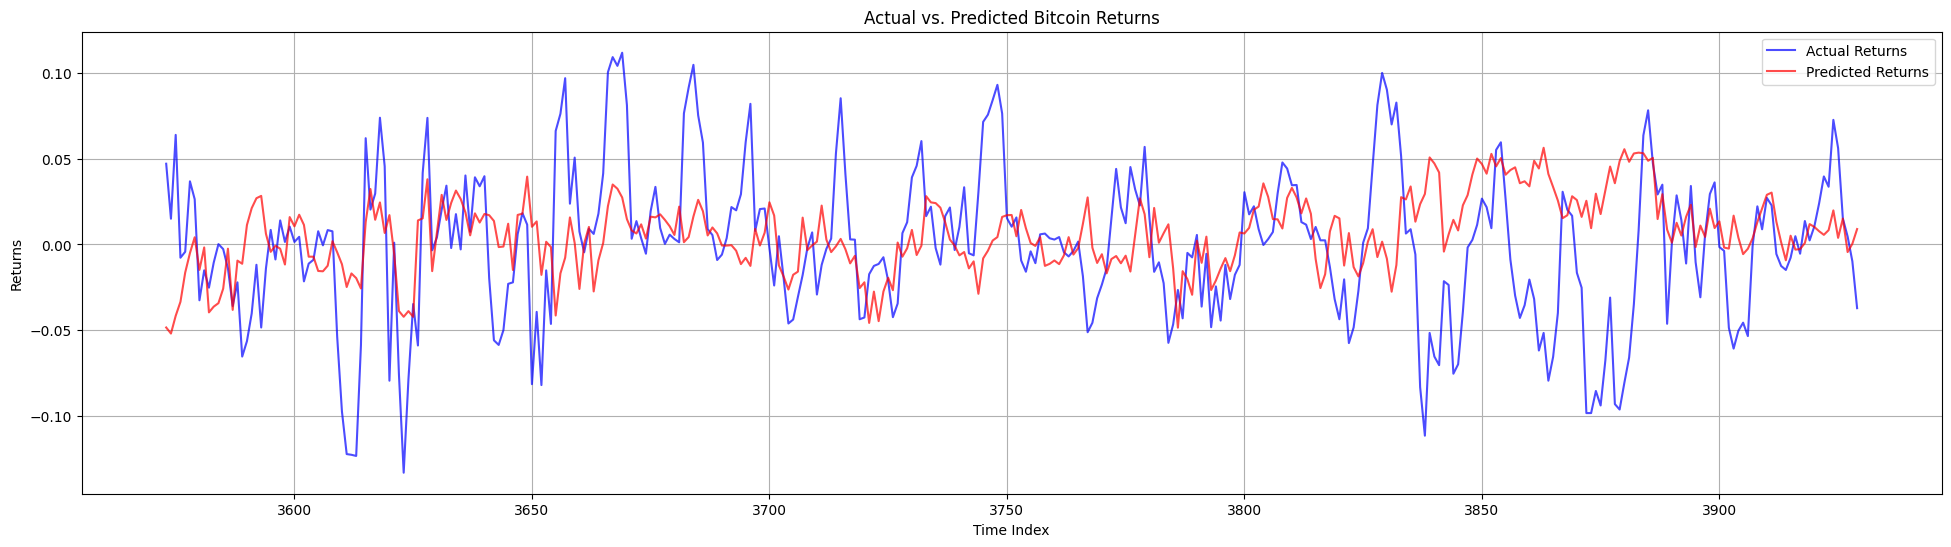

In [13]:
threshold = 0.008

signals = np.where(y_pred > threshold, 1,
          np.where(y_pred < -threshold, -1, 0))

mask = signals != 0

direction_acc = np.mean((signals[mask] > 0) == (y_test[mask] > 0))

print("Filtered Accuracy:", direction_acc)
print("Trade %:", np.mean(mask))


plt.figure(figsize=(24, 6))
plt.plot(y_test.index, y_test, label='Actual Returns', color='blue', alpha=0.7)
plt.plot(y_test.index, y_pred, label='Predicted Returns', color='red', alpha=0.7)
plt.title('Actual vs. Predicted Bitcoin Returns')
plt.xlabel('Time Index')
plt.ylabel('Returns')
plt.legend()
plt.grid(True)
plt.show()


Direction Accuracy:     57.14%
Sharpe Ratio:           0.209
Max Drawdown:           -83.08%
Final Strategy Return:  0.878x
Final Market Return:    0.604x


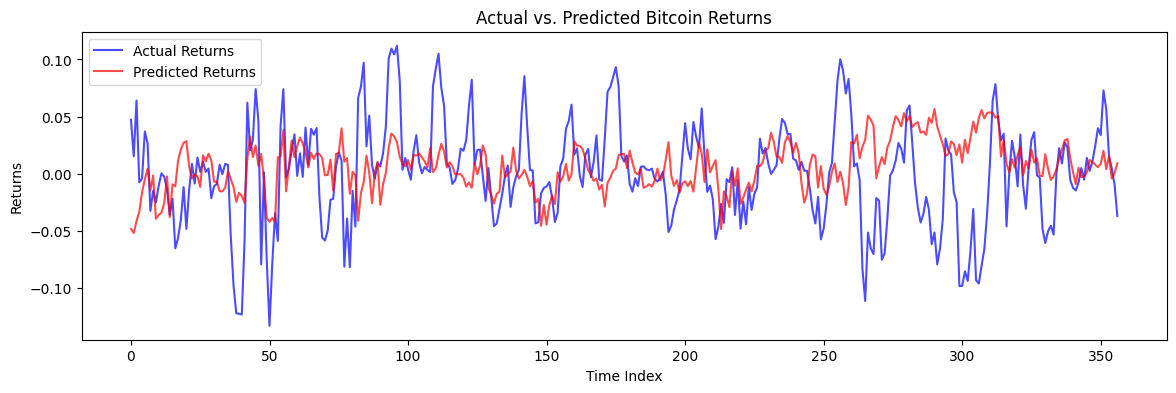

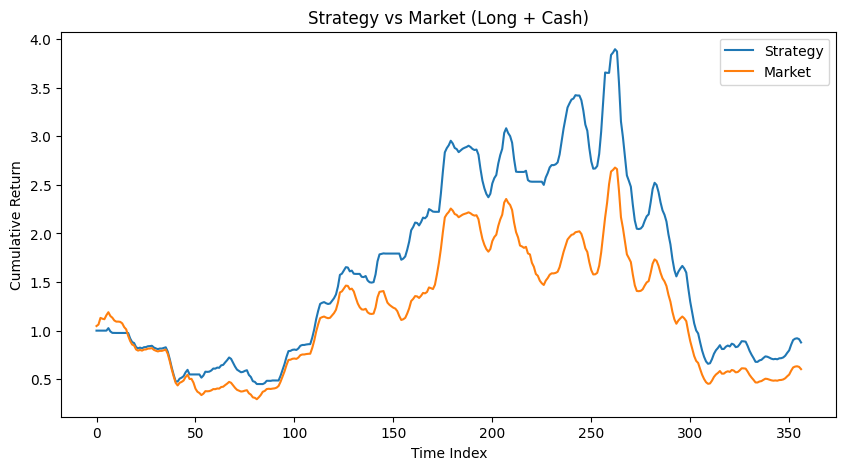

In [14]:
threshold_enter = 0.001
threshold_exit = -0.025   # exit to cash if pred < this
                          # between the two = hold current position

position = np.zeros(len(y_pred))
current_pos = 1  # start invested

for i in range(len(y_pred)):
    if y_pred[i] > threshold_enter:
        current_pos = 1   # go/stay long
    elif y_pred[i] < threshold_exit:
        current_pos = 0   # exit to cash
    position[i] = current_pos

# Apply returns
strategy_returns = position * y_test.values

# Transaction cost only when position changes
trades = np.abs(np.diff(position, prepend=0))
cost = 0.001
strategy_returns = strategy_returns - cost * trades

# Cumulative
cumulative_strategy = pd.Series((1 + strategy_returns).cumprod())
cumulative_market = pd.Series((1 + y_test.values).cumprod())

# ----------------------------------------
# METRICS
# ----------------------------------------
sharpe = (strategy_returns.mean() / strategy_returns.std()) * np.sqrt(365)
drawdown = (cumulative_strategy / cumulative_strategy.cummax() - 1).min()
direction_acc = np.mean((y_pred > 0) == (y_test.values > 0))

print(f"Direction Accuracy:     {direction_acc:.2%}")
print(f"Sharpe Ratio:           {sharpe:.3f}")
print(f"Max Drawdown:           {drawdown:.2%}")
print(f"Final Strategy Return:  {cumulative_strategy.iloc[-1]:.3f}x")
print(f"Final Market Return:    {cumulative_market.iloc[-1]:.3f}x")

# ----------------------------------------
# PLOT 1 - Actual vs Predicted Returns
# ----------------------------------------
plt.figure(figsize=(14, 4))
plt.plot(y_test.values, label='Actual Returns', color='blue', alpha=0.7)
plt.plot(y_pred, label='Predicted Returns', color='red', alpha=0.7)
plt.title('Actual vs. Predicted Bitcoin Returns')
plt.xlabel('Time Index')
plt.ylabel('Returns')
plt.legend()
plt.show()

# ----------------------------------------
# PLOT 2 - Strategy vs Market
# ----------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(cumulative_strategy, label='Strategy')
plt.plot(cumulative_market, label='Market')
plt.legend()
plt.title('Strategy vs Market (Long + Cash)')
plt.xlabel('Time Index')
plt.ylabel('Cumulative Return')
plt.show()

# LSTM Model -- Deep-Learning Comparator
The LSTM regressor lives in `BackEnd/Model/lstm.py` and consumes the same 46
feature columns produced by `feature_conversion()`. It targets the same 5-day
forward cumulative return as XGBoost so the two models can be compared
apples-to-apples in the cells below and exposed through identical
`/predict?model_use=...` JSON shapes.

In [ ]:
# Walk-forward evaluation of the LSTM (3 folds; LSTM training dominates wall-time
# so we keep the fold count below the XGB pipeline's 10).
from Model.lstm import walk_forward_eval_lstm, DEFAULT_SEQ_LEN

# `featData` was built in cell 10 with feature_conversion(). X and y were defined in cell 11.
print(f'features: {X.shape}, target std: {y.std():.4f}')
print(f'sequence length: {DEFAULT_SEQ_LEN} days, horizon: 5-day cumulative return')

lstm_fold_metrics = walk_forward_eval_lstm(X, y, n_splits=3, seq_len=DEFAULT_SEQ_LEN)
print('\nLSTM walk-forward fold metrics:')
print(lstm_fold_metrics.to_string(index=False))


In [ ]:
# Final fit on the full history, then persist the artifact.
import json as _json
from Model.lstm import train_lstm, save_artifact, DEFAULT_SEQ_LEN

trained_through = str(pd.to_datetime(data['Date']).max().date())
artifact, train_losses, val_losses = train_lstm(
    X, y,
    seq_len=DEFAULT_SEQ_LEN,
    trained_through=trained_through,
    verbose=True,
)
paths = save_artifact(artifact)

# Plot the training/val loss curve for the final fit.
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.title('LSTM final-fit loss (Huber)')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Side-by-side comparison: XGB tuned summary (already loaded into `result`
# earlier in this notebook) vs LSTM walk-forward summary (just computed).
xgb_summary = result.extras['tuned_summary']
lstm_summary = {
    'rmse_mean': float(lstm_fold_metrics['rmse'].mean()),
    'rmse_std':  float(lstm_fold_metrics['rmse'].std()),
    'mae_mean':  float(lstm_fold_metrics['mae'].mean()),
    'dir_acc_mean': float(lstm_fold_metrics['dir_acc'].mean()),
    'dir_acc_filtered_mean': float(lstm_fold_metrics['dir_acc_filtered'].mean(skipna=True)),
    'direction_aware_score_mean': float(lstm_fold_metrics['direction_aware_score'].mean()),
    'pred_std_mean': float(lstm_fold_metrics['pred_std'].mean()),
}
comparison = pd.DataFrame({'XGBoost': xgb_summary, 'LSTM': lstm_summary})
print('\nWalk-forward comparison (XGB 10-fold vs LSTM 3-fold):')
print(comparison.to_string())

print('\nSaved LSTM artifacts:')
for k, v in paths.items():
    print(f'  {k}: {v}')

print('\nLSTM final-fit metrics:')
print(_json.dumps(artifact.train_metrics, indent=2))
